# Lab 02: System Requirements & Software Architecture

## Task 1: Functional & Non-Functional Requirements

**Smart Automated Attendance System**

### Functional Requirements

| ID | Functional Requirement | Measure |
|----|------------------------|---------|
| FR1 | Detect all faces in each camera frame | Under 200 ms per frame |
| FR2 | Match each detected face to an enrolled student | Returns student ID and confidence score |
| FR3 | Log attendance with student ID, course, date and time | One record per student per session |
| FR4 | Sync local records to the central database | Every 5 minutes, retry on failure |
| FR5 | Export attendance reports | CSV or PDF by class and date range |

### Non-Functional Requirements

| ID | Non-Functional Requirement | Target |
|----|----------------------------|--------|
| NFR1 | Frame rate on the edge device | At least 15 FPS |
| NFR2 | Recognition accuracy | At least 95% accuracy, false accept rate under 1% |
| NFR3 | Edge device power usage | 15 W or less |
| NFR4 | Data privacy | Face embeddings encrypted (AES-256), raw video deleted within 24 hours |
| NFR5 | Availability | 99% uptime in class hours, works offline for 24 hours |

## Task 2: System Boundary, Actors and Input/Output Mapping

**AI Surveillance Application**

### Actors

| Actor | Role |
|-------|------|
| Security Operator | Watches live alerts and confirms or dismisses them |
| Administrator | Sets thresholds, manages cameras and reviews reports |
| IP Camera | Supplies the video stream |
| Automated Trigger System | Raises alerts when a rule matches (person in restricted zone) |

### Inputs

| Input | Specification |
|-------|---------------|
| Video stream | RTSP, H.264, 1920x1080, 25 FPS |
| Sensor parameters | Exposure, night mode, camera ID, zone ID |
| Configuration file | Confidence threshold, alert classes, ROI polygon |
| Model weights | YOLO `.pt` file |

### Outputs

| Output | Specification |
|--------|---------------|
| Bounding boxes | `x1, y1, x2, y2`, class name, confidence |
| Alert notifications | Dashboard popup, email or SMS |
| Log entries | Timestamp, class, confidence, box coordinates |
| Snapshots | JPEG saved as `YYYYMMDD_HHMMSS.jpg` |

### Operational Constraints

| Constraint | Limit |
|------------|-------|
| Memory footprint | 4 GB RAM, 2 GB GPU memory |
| Bandwidth | 4 Mbps per camera stream |
| End-to-end latency | 500 ms from frame to alert |
| Storage | 50 GB, snapshots kept 30 days |

## Task 3: Data-Flow Diagrams

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Ellipse


def entity(ax, x, y, text):
    ax.add_patch(Rectangle((x - 1, y - 0.4), 2, 0.8, facecolor='#dbeafe', edgecolor='black'))
    ax.text(x, y, text, ha='center', va='center', fontsize=9)


def process(ax, x, y, text, w=3.0, h=1.7):
    ax.add_patch(Ellipse((x, y), w, h, facecolor='#dcfce7', edgecolor='black'))
    ax.text(x, y, text, ha='center', va='center', fontsize=9)


def store(ax, x, y, text):
    ax.plot([x - 1.1, x + 1.1], [y + 0.4, y + 0.4], color='black')
    ax.plot([x - 1.1, x + 1.1], [y - 0.4, y - 0.4], color='black')
    ax.text(x, y, text, ha='center', va='center', fontsize=9)


def flow(ax, start, end, label, rad=0, dx=0, dy=0.1, va='bottom'):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', connectionstyle=f'arc3,rad={rad}'))
    ax.text((start[0] + end[0]) / 2 + dx, (start[1] + end[1]) / 2 + dy, label,
            ha='center', va=va, fontsize=8)


def new_canvas(width, height, xmin, xmax, ymin, ymax, title):
    fig, ax = plt.subplots(figsize=(width, height))
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axis('off')
    ax.set_title(title, fontsize=14)
    return fig, ax

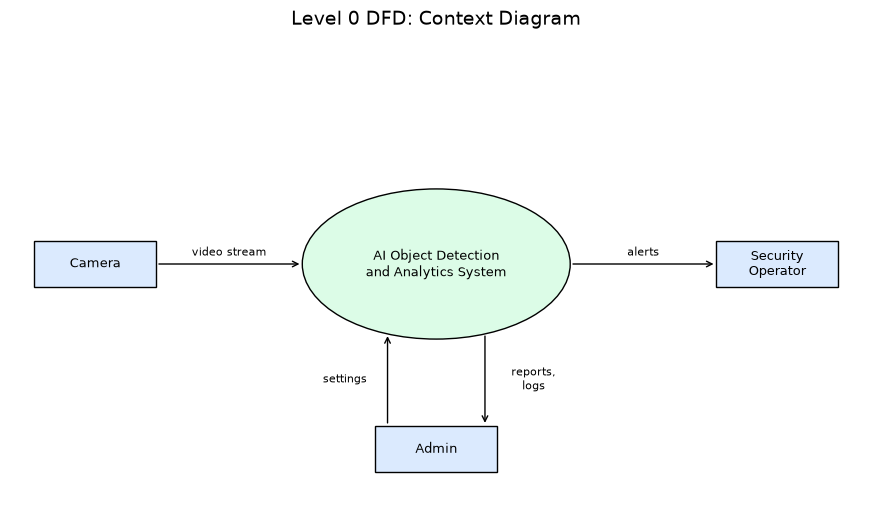

In [2]:
fig, ax = new_canvas(11, 6, 0, 14, 0, 8, 'Level 0 DFD: Context Diagram')

entity(ax, 1.4, 4, 'Camera')
process(ax, 7, 4, 'AI Object Detection\nand Analytics System', w=4.4, h=2.6)
entity(ax, 12.6, 4, 'Security\nOperator')
entity(ax, 7, 0.8, 'Admin')

flow(ax, (2.4, 4), (4.8, 4), 'video stream')
flow(ax, (9.2, 4), (11.6, 4), 'alerts')
flow(ax, (6.2, 1.2), (6.2, 2.8), 'settings', dx=-0.7, dy=0, va='center')
flow(ax, (7.8, 2.8), (7.8, 1.2), 'reports,\nlogs', dx=0.8, dy=0, va='center')

fig.savefig('dfd_level0.png', dpi=300, bbox_inches='tight')
plt.show()

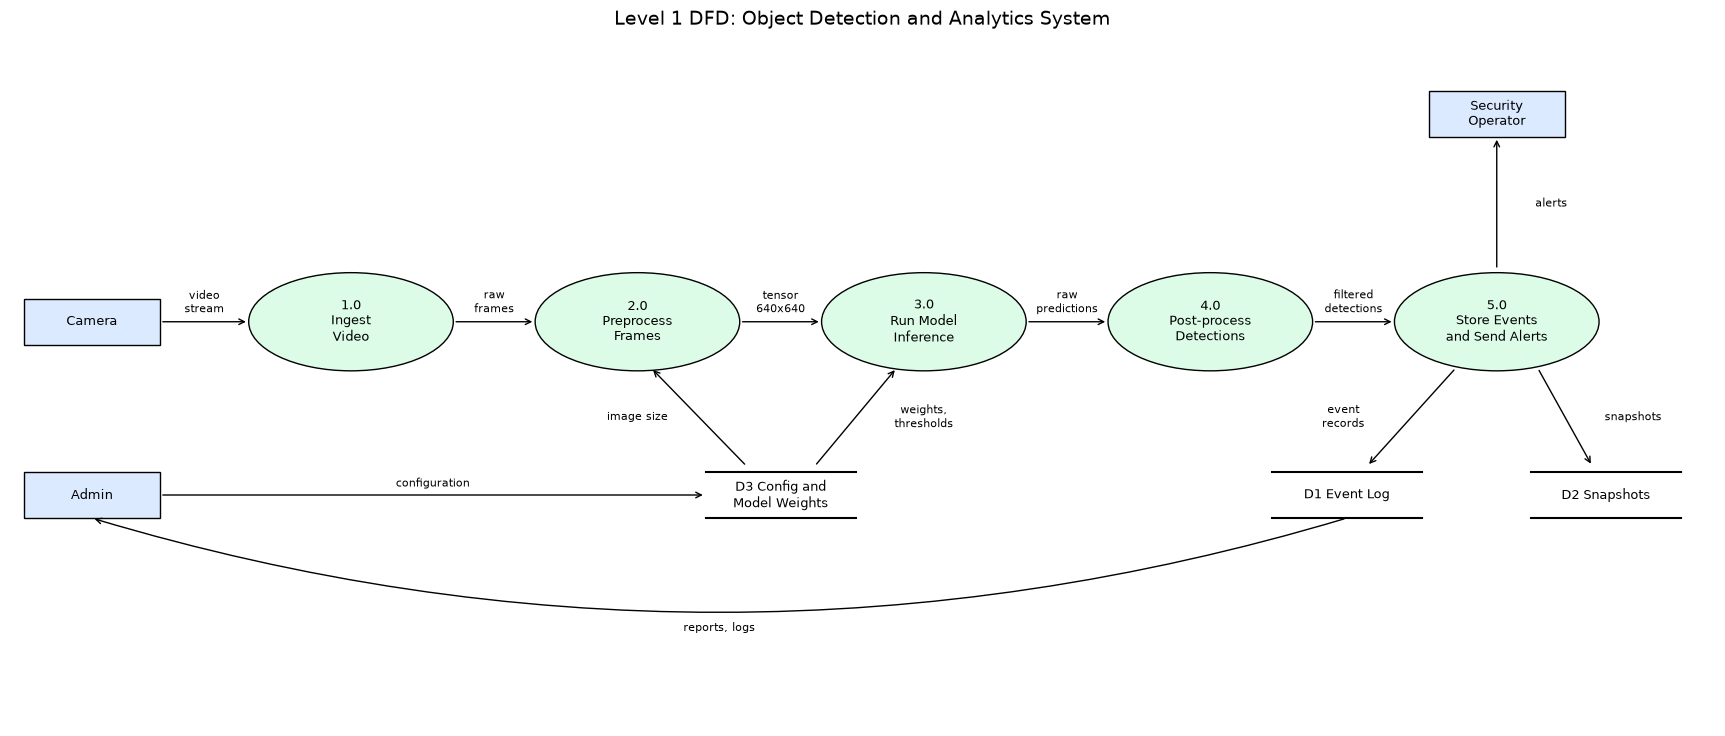

In [3]:
fig, ax = new_canvas(22, 9, 0, 25, -3, 9, 'Level 1 DFD: Object Detection and Analytics System')

entity(ax, 1.2, 4, 'Camera')
process(ax, 5, 4, '1.0\nIngest\nVideo')
process(ax, 9.2, 4, '2.0\nPreprocess\nFrames')
process(ax, 13.4, 4, '3.0\nRun Model\nInference')
process(ax, 17.6, 4, '4.0\nPost-process\nDetections')
process(ax, 21.8, 4, '5.0\nStore Events\nand Send Alerts')

entity(ax, 1.2, 1, 'Admin')
store(ax, 11.3, 1, 'D3 Config and\nModel Weights')
store(ax, 19.6, 1, 'D1 Event Log')
store(ax, 23.4, 1, 'D2 Snapshots')
entity(ax, 21.8, 7.6, 'Security\nOperator')

flow(ax, (2.2, 4), (3.5, 4), 'video\nstream')
flow(ax, (6.5, 4), (7.7, 4), 'raw\nframes')
flow(ax, (10.7, 4), (11.9, 4), 'tensor\n640x640')
flow(ax, (14.9, 4), (16.1, 4), 'raw\npredictions')
flow(ax, (19.1, 4), (20.3, 4), 'filtered\ndetections')

flow(ax, (2.2, 1), (10.2, 1), 'configuration')
flow(ax, (10.8, 1.5), (9.4, 3.2), 'image size', dx=-0.9, dy=0, va='center')
flow(ax, (11.8, 1.5), (13.0, 3.2), 'weights,\nthresholds', dx=1.0, dy=0, va='center')
flow(ax, (21.2, 3.2), (19.9, 1.5), 'event\nrecords', dx=-1.0, dy=0, va='center')
flow(ax, (22.4, 3.2), (23.2, 1.5), 'snapshots', dx=1.0, dy=0, va='center')
flow(ax, (21.8, 4.9), (21.8, 7.2), 'alerts', dx=0.8, dy=0, va='center')
flow(ax, (19.6, 0.6), (1.2, 0.6), 'reports, logs', rad=-0.15, dy=-1.9, va='center')

fig.savefig('dfd_level1.png', dpi=300, bbox_inches='tight')
plt.show()

## Task 4: Modular Software Architecture

| Module | Responsibility | Input | Output |
|--------|----------------|-------|--------|
| DataIngestion | Opens a camera, video file or RTSP stream and reads frames | Source string | Frame (`np.ndarray`) |
| ImagePreprocessor | Letterbox resize to 640x640 and normalize to 0.0 to 1.0 | BGR frame | `float32` array |
| ModelInferenceEngine | Loads YOLO weights and runs detection | Frame | List of detection dictionaries |
| AlertLogger | Checks priority classes, saves snapshots, writes the event log, sends alerts | Frame and detections | Snapshot path, log entry |

In [4]:
import os

os.makedirs('src', exist_ok=True)

In [5]:
%%writefile src/data_ingestion.py
from typing import Optional, Tuple

import numpy as np


class DataIngestion:
    def __init__(self, source: str, width: int = 1280, height: int = 720) -> None:
        pass

    def open(self) -> bool:
        pass

    def is_opened(self) -> bool:
        pass

    def read_frame(self) -> Tuple[bool, Optional[np.ndarray]]:
        pass

    def release(self) -> None:
        pass

Overwriting src/data_ingestion.py


In [6]:
%%writefile src/image_preprocessor.py
from typing import Tuple

import numpy as np


class ImagePreprocessor:
    def __init__(self, target_size: Tuple[int, int] = (640, 640)) -> None:
        pass

    def letterbox(self, frame: np.ndarray) -> np.ndarray:
        pass

    def normalize(self, frame: np.ndarray) -> np.ndarray:
        pass

    def process(self, frame: np.ndarray) -> np.ndarray:
        pass

Overwriting src/image_preprocessor.py


In [7]:
%%writefile src/model_inference_engine.py
from typing import Dict, List

import numpy as np


class ModelInferenceEngine:
    def __init__(self, model_path: str = 'yolov8n.pt', conf_threshold: float = 0.5) -> None:
        pass

    def load_model(self) -> None:
        pass

    def predict(self, frame: np.ndarray) -> List[Dict]:
        pass

    def get_class_names(self) -> Dict[int, str]:
        pass

Overwriting src/model_inference_engine.py


In [8]:
%%writefile src/alert_logger.py
from typing import Dict, List

import numpy as np


class AlertLogger:
    def __init__(self, log_path: str = 'logs/events.log', alert_dir: str = 'alerts') -> None:
        pass

    def should_alert(self, detections: List[Dict], priority_classes: List[str], threshold: float) -> bool:
        pass

    def save_snapshot(self, frame: np.ndarray) -> str:
        pass

    def log_event(self, detection: Dict) -> None:
        pass

    def send_alert(self, message: str) -> None:
        pass

Overwriting src/alert_logger.py


## Task 5: ARCHITECTURE.md

In [9]:
from IPython.display import Markdown

Markdown(open('ARCHITECTURE.md', encoding='utf-8').read())

# System Design Specification: AI Object Detection and Analytics System

**Course:** AI Project Design and Development (AI-316)
**Author:** Abdul Rehman Ali

## 1. Requirements

### 1.1 Functional Requirements (Smart Automated Attendance System)

| ID | Functional Requirement | Measure |
|----|------------------------|---------|
| FR1 | Detect all faces in each camera frame | Under 200 ms per frame |
| FR2 | Match each detected face to an enrolled student | Returns student ID and confidence score |
| FR3 | Log attendance with student ID, course, date and time | One record per student per session |
| FR4 | Sync local records to the central database | Every 5 minutes, retry on failure |
| FR5 | Export attendance reports | CSV or PDF by class and date range |

### 1.2 Non-Functional Requirements

| ID | Non-Functional Requirement | Target |
|----|----------------------------|--------|
| NFR1 | Frame rate on the edge device | At least 15 FPS |
| NFR2 | Recognition accuracy | At least 95% accuracy, false accept rate under 1% |
| NFR3 | Edge device power usage | 15 W or less |
| NFR4 | Data privacy | Face embeddings encrypted (AES-256), raw video deleted within 24 hours |
| NFR5 | Availability | 99% uptime in class hours, works offline for 24 hours |

## 2. System Boundary and Input/Output Mapping

### 2.1 Actors

| Actor | Role |
|-------|------|
| Security Operator | Watches live alerts and confirms or dismisses them |
| Administrator | Sets thresholds, manages cameras and reviews reports |
| IP Camera | Supplies the video stream |
| Automated Trigger System | Raises alerts when a rule matches (person in restricted zone) |

### 2.2 Inputs

| Input | Specification |
|-------|---------------|
| Video stream | RTSP, H.264, 1920x1080, 25 FPS |
| Sensor parameters | Exposure, night mode, camera ID, zone ID |
| Configuration file | Confidence threshold, alert classes, ROI polygon |
| Model weights | YOLO `.pt` file |

### 2.3 Outputs

| Output | Specification |
|--------|---------------|
| Bounding boxes | `x1, y1, x2, y2`, class name, confidence |
| Alert notifications | Dashboard popup, email or SMS |
| Log entries | Timestamp, class, confidence, box coordinates |
| Snapshots | JPEG saved as `YYYYMMDD_HHMMSS.jpg` |

### 2.4 Operational Constraints

| Constraint | Limit |
|------------|-------|
| Memory footprint | 4 GB RAM, 2 GB GPU memory |
| Bandwidth | 4 Mbps per camera stream |
| End-to-end latency | 500 ms from frame to alert |
| Storage | 50 GB, snapshots kept 30 days |

## 3. Data-Flow Diagrams

### 3.1 Level 0 (Context Diagram)
```mermaid
flowchart LR
    CAM[Camera] -->|video stream| SYS((AI Object Detection and Analytics System))
    ADM[Admin] -->|settings| SYS
    SYS -->|alerts| OP[Security Operator]
    SYS -->|reports, logs| ADM
```

![Level 0 DFD](dfd_level0.png)

### 3.2 Level 1
```mermaid
flowchart LR
    CAM[Camera] -->|video stream| P1((1.0 Ingest Video))
    P1 -->|raw frames| P2((2.0 Preprocess Frames))
    P2 -->|640x640 tensor| P3((3.0 Run Model Inference))
    P3 -->|raw predictions| P4((4.0 Post-process Detections))
    P4 -->|filtered detections| P5((5.0 Store Events and Send Alerts))
    ADM[Admin] -->|configuration| D3[(D3 Config and Model Weights)]
    D3 -->|image size| P2
    D3 -->|weights, thresholds| P3
    P5 -->|event records| D1[(D1 Event Log)]
    P5 -->|snapshots| D2[(D2 Snapshot Storage)]
    P5 -->|alerts| OP[Security Operator]
    D1 -->|reports, logs| ADM
```

![Level 1 DFD](dfd_level1.png)

## 4. Modular Software Architecture

### 4.1 Module Overview

| Module | Responsibility | Input | Output |
|--------|----------------|-------|--------|
| DataIngestion | Opens a camera, video file or RTSP stream and reads frames | Source string | Frame (`np.ndarray`) |
| ImagePreprocessor | Letterbox resize to 640x640 and normalize to 0.0 to 1.0 | BGR frame | `float32` array |
| ModelInferenceEngine | Loads YOLO weights and runs detection | Frame | List of detection dictionaries |
| AlertLogger | Checks priority classes, saves snapshots, writes the event log, sends alerts | Frame and detections | Snapshot path, log entry |

### 4.2 Class Definitions

**src/data_ingestion.py**
```python
from typing import Optional, Tuple

import numpy as np


class DataIngestion:
    def __init__(self, source: str, width: int = 1280, height: int = 720) -> None:
        pass

    def open(self) -> bool:
        pass

    def is_opened(self) -> bool:
        pass

    def read_frame(self) -> Tuple[bool, Optional[np.ndarray]]:
        pass

    def release(self) -> None:
        pass
```

**src/image_preprocessor.py**
```python
from typing import Tuple

import numpy as np


class ImagePreprocessor:
    def __init__(self, target_size: Tuple[int, int] = (640, 640)) -> None:
        pass

    def letterbox(self, frame: np.ndarray) -> np.ndarray:
        pass

    def normalize(self, frame: np.ndarray) -> np.ndarray:
        pass

    def process(self, frame: np.ndarray) -> np.ndarray:
        pass
```

**src/model_inference_engine.py**
```python
from typing import Dict, List

import numpy as np


class ModelInferenceEngine:
    def __init__(self, model_path: str = 'yolov8n.pt', conf_threshold: float = 0.5) -> None:
        pass

    def load_model(self) -> None:
        pass

    def predict(self, frame: np.ndarray) -> List[Dict]:
        pass

    def get_class_names(self) -> Dict[int, str]:
        pass
```

**src/alert_logger.py**
```python
from typing import Dict, List

import numpy as np


class AlertLogger:
    def __init__(self, log_path: str = 'logs/events.log', alert_dir: str = 'alerts') -> None:
        pass

    def should_alert(self, detections: List[Dict], priority_classes: List[str], threshold: float) -> bool:
        pass

    def save_snapshot(self, frame: np.ndarray) -> str:
        pass

    def log_event(self, detection: Dict) -> None:
        pass

    def send_alert(self, message: str) -> None:
        pass
```

### 4.3 Detection Format

Each item returned by `ModelInferenceEngine.predict` is a dictionary:

```python
{'bbox': (x1, y1, x2, y2), 'confidence': 0.91, 'class_id': 0, 'class_name': 'person'}
```


In [10]:
!git add ARCHITECTURE.md src dfd_level0.png dfd_level1.png
!git commit -m "Add system architecture document and module skeletons"
!git log --oneline

[master (root-commit) 3996789] Add system architecture document and module skeletons
 8 files changed, 362 insertions(+)
 create mode 100644 OneDrive/Documents/vs code/AIPDD/Lab02/AI_Project/ARCHITECTURE.md
 create mode 100644 OneDrive/Documents/vs code/AIPDD/Lab02/AI_Project/dfd_level0.png
 create mode 100644 OneDrive/Documents/vs code/AIPDD/Lab02/AI_Project/dfd_level1.png
 create mode 100644 OneDrive/Documents/vs code/AIPDD/Lab02/AI_Project/src/alert_logger.py
 create mode 100644 OneDrive/Documents/vs code/AIPDD/Lab02/AI_Project/src/data_ingestion.py
 create mode 100644 OneDrive/Documents/vs code/AIPDD/Lab02/AI_Project/src/image_preprocessor.py
 create mode 100644 OneDrive/Documents/vs code/AIPDD/Lab02/AI_Project/src/model_inference_engine.py
 create mode 100644 OneDrive/Documents/vs code/Face recognition attendance/main.py
3996789 Add system architecture document and module skeletons
